# Lab — Préparation des données : Adult Census Income

**Dataset :** [Adult – UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/2/adult)

Ce notebook couvre l’ensemble du livrable technique (sans présentation) :
1. Business Understanding  
2. Data Understanding  
3. Data Exploration  
4. Data Preparation  
5. Segmentation (clustering)  
6. Classification  
7. Évaluation et interprétation  

**Prérequis :** placer `adult.data` et `adult.test` dans le même dossier que ce notebook, puis :
```bash
pip install -r requirements.txt
```

---
## 1. Business Understanding

### Contexte
Les données proviennent du recensement américain de **1994**. Chaque ligne décrit une personne (âge, emploi, éducation, etc.) et si son revenu annuel est **≤ 50 000 $** ou **> 50 000 $**.

### Problématique métier
- **Classification :** prédire si un individu gagne plus de 50K$/an à partir de variables socio-professionnelles (ciblage marketing, études d’équité, aide à la décision).
- **Segmentation :** regrouper des profils similaires (sans utiliser le revenu) pour comprendre des **typologies de population** (politiques RH, études descriptives).

### Critères de succès
- Données **fiables et documentées** après nettoyage.
- Modèle de classification avec métriques adaptées au **déséquilibre des classes** (~24 % >50K).
- Segments **interprétables** (profils moyens par cluster).

### Contraintes
- Valeurs manquantes codées `?`.
- Split officiel train (`adult.data`) / test (`adult.test`) imposé par UCI.

---
## 2. Data Understanding

Chargement des fichiers, définition des colonnes et premières statistiques descriptives.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_DIR = Path(".")
RANDOM_STATE = 42

COLUMN_NAMES = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income",
]

NA_VALUES = ["?", " ?", "? "]

In [2]:
def load_adult(path: Path) -> pd.DataFrame:
    """Charge un fichier Adult (train ou test UCI)."""
    df = pd.read_csv(
        path,
        header=None,
        names=COLUMN_NAMES,
        na_values=NA_VALUES,
        skiprows=lambda x: x == 0 and path.name == "adult.test",
        skip_blank_lines=True,
        comment="|",
        engine="python",
    )
    df["income"] = df["income"].astype(str).str.strip().str.rstrip(".")
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip()
    return df


train_raw = load_adult(DATA_DIR / "adult.data")
test_raw = load_adult(DATA_DIR / "adult.test")

print(f"Train : {train_raw.shape[0]} lignes, Test : {test_raw.shape[0]} lignes")
display(train_raw.head())
display(train_raw.info())
display(train_raw.describe(include="all").T)

Train : 32561 lignes, Test : 16281 lignes


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,32561.0,NaN,NaN,NaN,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
workclass,30725,8,Private,22696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,32561.0,NaN,NaN,NaN,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education,32561,16,HS-grad,10501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,32561.0,NaN,NaN,NaN,10.080679,2.57272,1.0,9.0,10.0,12.0,16.0
marital-status,32561,7,Married-civ-spouse,14976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,30718,14,Prof-specialty,4140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,32561,6,Husband,13193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,32561,5,White,27816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,32561,2,Male,21790,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Dictionnaire des variables (résumé)

| Variable | Type | Description |
|----------|------|-------------|
| age | numérique | Âge en années |
| workclass | catégorielle | Secteur d’emploi |
| fnlwgt | numérique | Poids d’échantillonnage census (non prédictif direct) |
| education / education-num | cat / num | Niveau d’éducation |
| marital-status, relationship | cat | Situation familiale |
| occupation | cat | Métier |
| race, sex, native-country | cat | Démographie |
| capital-gain, capital-loss | num | Revenus du capital |
| hours-per-week | num | Heures travaillées |
| **income** | **cible** | `<=50K` ou `>50K` |

---
## 3. Data Exploration

Objectifs : distributions, relations, anomalies potentielles, déséquilibre de la cible.

In [3]:
df = train_raw.copy()

print("=== Valeurs manquantes (train) ===")
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
display(pd.DataFrame({"missing": missing, "pct": missing_pct}))

print("\n=== Distribution de la cible ===")
print(df["income"].value_counts(normalize=True).round(4))

=== Valeurs manquantes (train) ===


,missing,pct
occupation,1843,5.66
workclass,1836,5.64
native-country,583,1.79
fnlwgt,0,0.00
education,0,0.00
education-num,0,0.00
age,0,0.00
marital-status,0,0.00
relationship,0,0.00
sex,0,0.00



=== Distribution de la cible ===
income
<=50K    0.7592
>50K     0.2408
Name: proportion, dtype: float64


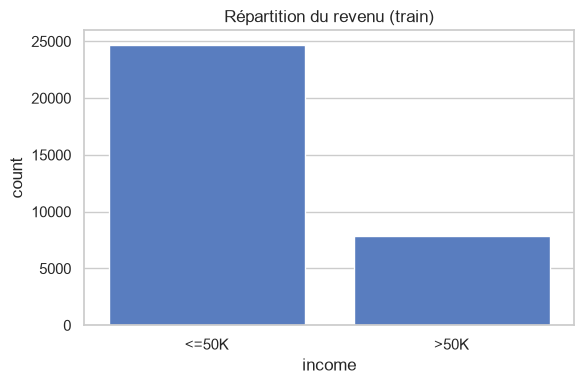

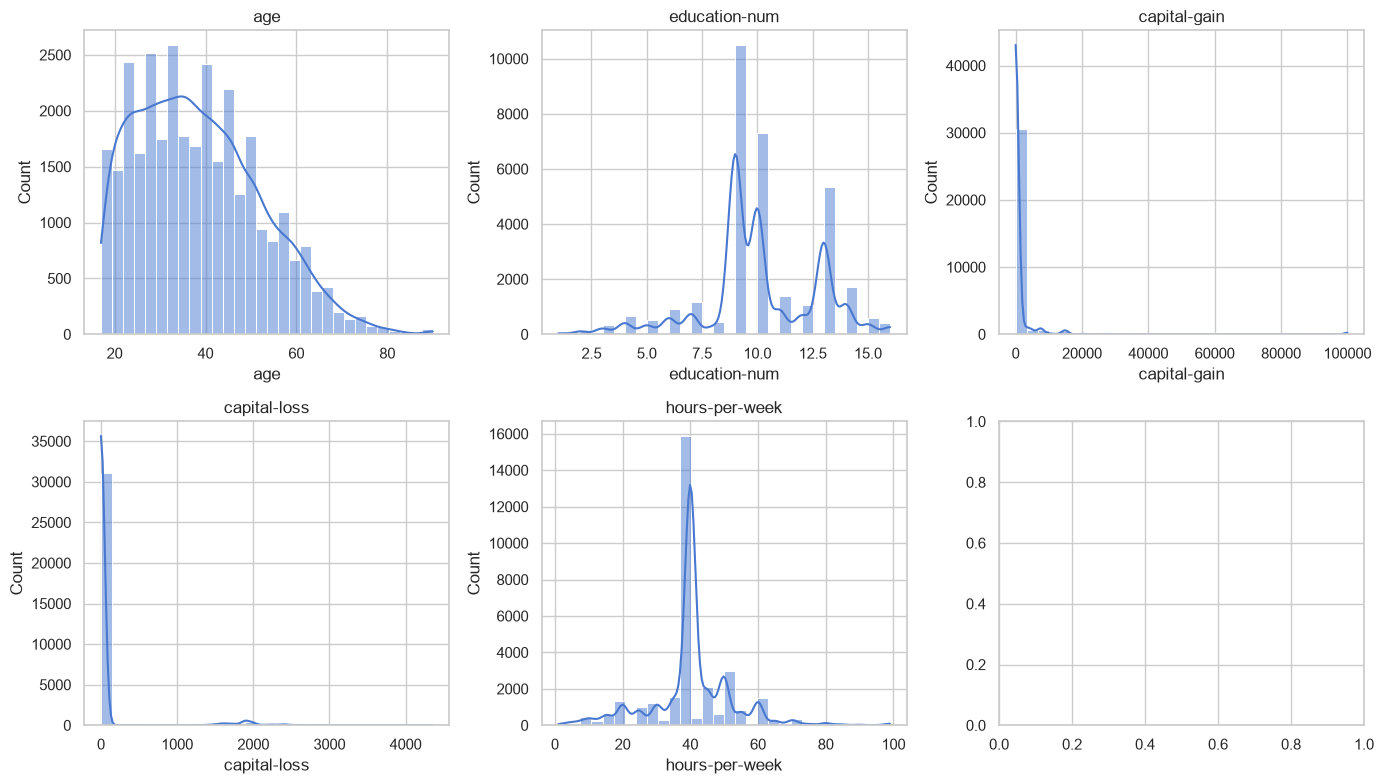

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="income", ax=ax)
ax.set_title("Répartition du revenu (train)")
plt.tight_layout()
plt.show()

num_cols = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

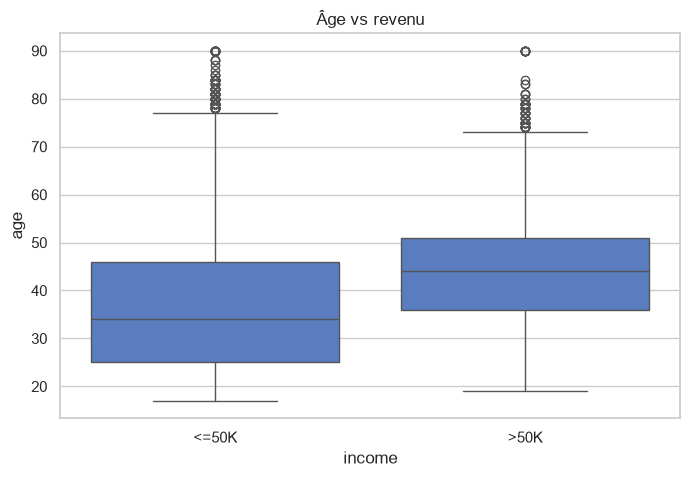

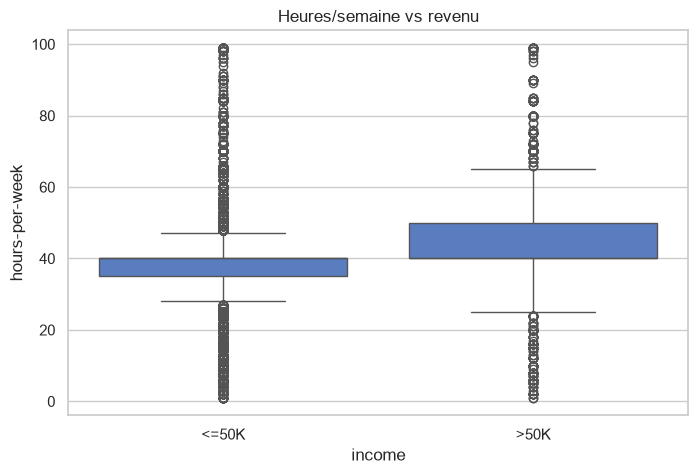

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="income", y="age", ax=ax)
ax.set_title("Âge vs revenu")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="income", y="hours-per-week", ax=ax)
ax.set_title("Heures/semaine vs revenu")
plt.show()

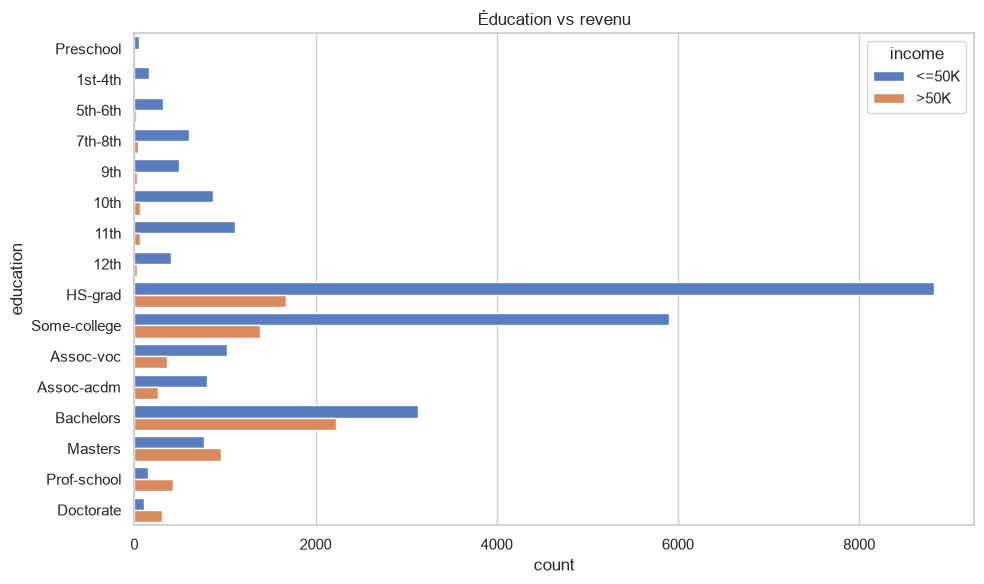

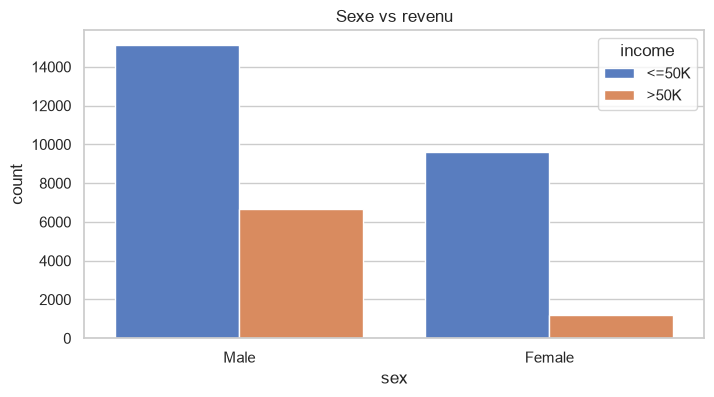

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
edu_order = df.groupby("education")["education-num"].mean().sort_values().index
sns.countplot(data=df, y="education", order=edu_order, hue="income", ax=ax)
ax.set_title("Éducation vs revenu")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=df, x="sex", hue="income", ax=ax)
ax.set_title("Sexe vs revenu")
plt.show()

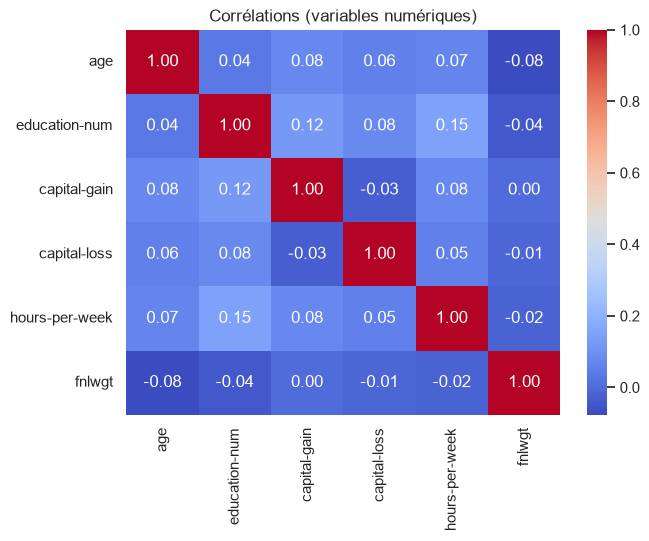

In [7]:
corr = df[["age", "education-num", "capital-gain", "capital-loss", "hours-per-week", "fnlwgt"]].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Corrélations (variables numériques)")
plt.show()

### Observations clés (à reprendre dans votre rapport)

1. **Classes déséquilibrées** : ~76 % `<=50K` — privilégier F1, recall sur la classe minoritaire, ROC-AUC.
2. **Manquants** : surtout `workclass`, `occupation`, `native-country` (codés `?`).
3. **capital-gain / capital-loss** : très asymétriques (beaucoup de 0, quelques valeurs élevées) — transformations ou modèles robustes.
4. **education** et **education-num** redondants — on peut ne garder qu’`education-num` pour éviter la fuite d’information redondante.
5. **fnlwgt** : poids d’enquête census, peu lié au revenu individuel — souvent **exclu** des modèles.
6. **Doublons** : UCI signale ~6 conflits — à vérifier.

In [8]:
dup = df.duplicated().sum()
print(f"Lignes dupliquées (train) : {dup}")

Lignes dupliquées (train) : 24


---
## 4. Data Preparation

Chaque choix est **justifié** ci-dessous puis appliqué dans le code.

| Problème | Choix | Justification |
|----------|--------|---------------|
| Manquants catégoriels | Imputation **mode** | Peu de lignes avec `?` ; le mode préserve la distribution la plus fréquente. Alternative : catégorie `Unknown` (utile si beaucoup de manquants). |
| Manquants numériques | Imputation **médiane** | Robuste aux outliers (capital-gain). |
| Doublons | **Suppression** | Évite de sur-représenter certains profils. |
| fnlwgt | **Suppression** | Variable de pondération d’enquête, pas une caractéristique individuelle stable pour la prédiction. |
| education (texte) | **Suppression** | `education-num` encode déjà le niveau ; évite double comptage après one-hot. |
| Outliers capital-gain/loss | **Conservation + log1p** (feature engineering) | Valeurs extrêmes sont **informatives** pour >50K ; le log compresse l’échelle sans supprimer l’info. |
| Outliers age / hours | **Conservation** | Plages plausibles (recensement) ; pas de winsorization agressive sans règle métier. |
| Catégorielles | **One-Hot Encoding** | Modèles linéaires et forêts ; pas d’ordre naturel pour workclass, occupation, etc. |
| Numériques pour clustering / LR | **StandardScaler** | K-Means et régression logistique sensibles à l’échelle. |

In [9]:
def prepare_dataframe(raw: pd.DataFrame, for_modeling: bool = True) -> pd.DataFrame:
    out = raw.copy()
    out = out.drop_duplicates()
    out = out.drop(columns=["fnlwgt", "education"], errors="ignore")

    out["capital-gain-log"] = np.log1p(out["capital-gain"].clip(lower=0))
    out["capital-loss-log"] = np.log1p(out["capital-loss"].clip(lower=0))
    out["is-us-born"] = (out["native-country"] == "United-States").astype(int)

    if for_modeling:
        cat_cols = out.select_dtypes(include="object").columns.tolist()
        if "income" in cat_cols:
            cat_cols.remove("income")
        num_cols = [
            c
            for c in out.columns
            if c not in cat_cols + ["income"]
        ]
        for col in cat_cols:
            mode_val = out[col].mode(dropna=True)
            fill = mode_val.iloc[0] if len(mode_val) else "Unknown"
            out[col] = out[col].fillna(fill)
        for col in num_cols:
            out[col] = out[col].fillna(out[col].median())
    return out


train_clean = prepare_dataframe(train_raw)
test_clean = prepare_dataframe(test_raw)

print(train_clean.shape, test_clean.shape)
display(train_clean.head())
print("Manquants après préparation :", train_clean.isna().sum().sum())

(32537, 16) (16276, 16)


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,capital-gain-log,capital-loss-log,is-us-born
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,7.684784,0.0,1
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0.000000,0.0,1
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0.000000,0.0,1
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0.000000,0.0,1
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0.000000,0.0,0


Manquants après préparation : 0


In [10]:
OUTPUT_CSV = DATA_DIR / "adult_cleaned_prepared.csv"
pd.concat([train_clean.assign(split="train"), test_clean.assign(split="test")]).to_csv(
    OUTPUT_CSV, index=False
)
print(f"Données nettoyées exportées : {OUTPUT_CSV.resolve()}")

Données nettoyées exportées : C:\Users\Hamza\Downloads\Notebook Adult\adult_cleaned_prepared.csv


In [11]:
TARGET = "income"
y_train = (train_clean[TARGET] == ">50K").astype(int)
y_test = (test_clean[TARGET] == ">50K").astype(int)

feature_cols = [c for c in train_clean.columns if c != TARGET]
X_train = train_clean[feature_cols]
X_test = test_clean[feature_cols]

cat_features = X_train.select_dtypes(include="object").columns.tolist()
num_features = [c for c in feature_cols if c not in cat_features]

print("Catégorielles :", cat_features)
print("Numériques :", num_features)

Catégorielles : ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numériques : ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'capital-gain-log', 'capital-loss-log', 'is-us-born']


In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            num_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ),
                ]
            ),
            cat_features,
        ),
    ]
)

---
## 5. Segmentation (Clustering)

### Problématique
Identifier des **profils types** d’individus actifs (sans utiliser `income`) à partir de l’âge, de l’éducation, des heures travaillées et de variables dérivées.

### Méthode
- **K-Means** sur variables numériques standardisées (interprétable, rapide sur ~30k lignes).
- Choix de **k** via **silhouette** sur un échantillon (coût calcul raisonnable).
- Visualisation **PCA** (2 composantes) pour illustrer la séparation.

In [13]:
cluster_cols = [
    "age",
    "education-num",
    "hours-per-week",
    "capital-gain-log",
    "capital-loss-log",
    "is-us-born",
]
X_clust = train_clean[cluster_cols].copy()
scaler_clust = StandardScaler()
X_clust_scaled = scaler_clust.fit_transform(X_clust)

sample_idx = np.random.default_rng(RANDOM_STATE).choice(
    len(X_clust_scaled), size=min(8000, len(X_clust_scaled)), replace=False
)
X_sample = X_clust_scaled[sample_idx]

k_range = range(2, 9)
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_sample)
    sil_scores.append(silhouette_score(X_sample, labels))

best_k = list(k_range)[int(np.argmax(sil_scores))]
print("Scores silhouette :", dict(zip(k_range, np.round(sil_scores, 3))))
print(f"k retenu : {best_k}")

Scores silhouette : {2: np.float64(0.414), 3: np.float64(0.433), 4: np.float64(0.478), 5: np.float64(0.297), 6: np.float64(0.32), 7: np.float64(0.334), 8: np.float64(0.334)}
k retenu : 4


In [14]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
train_clean["cluster"] = kmeans.fit_predict(X_clust_scaled)

profile = train_clean.groupby("cluster")[cluster_cols + ["capital-gain", "capital-loss"]].mean().round(2)
display(profile)

cluster_income = pd.crosstab(train_clean["cluster"], train_clean["income"], normalize="index").round(3)
print("\nProportion de revenu par cluster (analyse croisée, la cible n'a pas été utilisée pour le clustering) :")
display(cluster_income)

,age,education-num,hours-per-week,capital-gain-log,capital-loss-log,is-us-born,capital-gain,capital-loss
cluster,,,,,,,,
0,37.97,10.04,40.01,0.00,0.00,1.00,0.02,0.00
1,44.10,11.16,43.59,8.85,0.00,0.93,13140.01,0.00
2,41.70,10.97,43.25,0.00,7.51,0.91,0.00,1871.43
3,37.35,9.08,39.86,0.12,0.00,0.00,44.70,0.00



Proportion de revenu par cluster (analyse croisée, la cible n'a pas été utilisée pour le clustering) :


income,<=50K,>50K
cluster,,
0,0.805,0.195
1,0.371,0.629
2,0.491,0.509
3,0.846,0.154


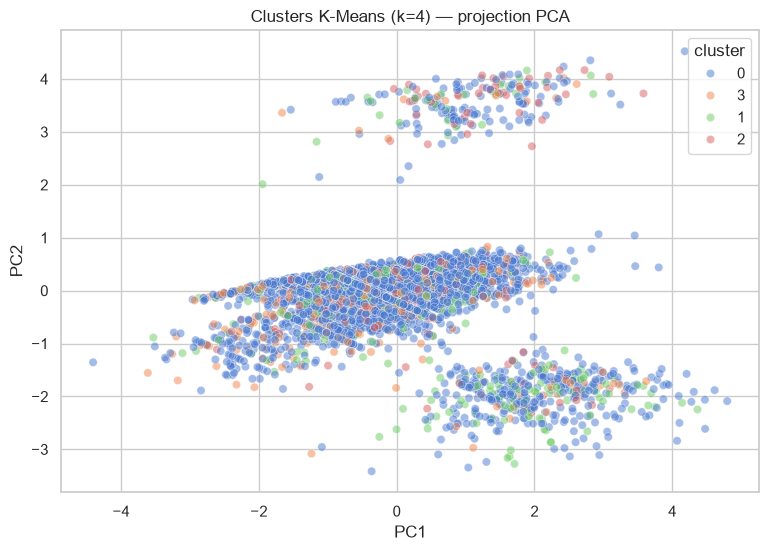

In [15]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_clust_scaled)
plot_df = pd.DataFrame(coords, columns=["PC1", "PC2"])
plot_df["cluster"] = train_clean["cluster"].astype(str)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=plot_df.sample(5000, random_state=RANDOM_STATE), x="PC1", y="PC2", hue="cluster", alpha=0.5, ax=ax)
ax.set_title(f"Clusters K-Means (k={best_k}) — projection PCA")
plt.show()

### Interprétation segmentation

Commentez le tableau `profile` : par exemple clusters avec **heures élevées + capital-gain** vs **jeunes + faible éducation-num**. La crosstab montre si certains segments sont associés à plus de `>50K` (validation descriptive, pas supervisée).

---
## 6. Classification

### Problématique
Prédire **income > 50K** (classe 1) vs **<= 50K** (classe 0).

### Modèles
1. **Régression logistique** — baseline interprétable, probabilités calibrables.
2. **Random Forest** — interactions non linéaires, robuste aux échelles après preprocessing.

Données : split UCI officiel. Pipeline = imputation + encodage + modèle (évite la fuite sur le test).

In [16]:
log_reg = Pipeline(
    steps=[
        ("prep", preprocessor),
        (
            "clf",
            LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
        ),
    ]
)

rf_clf = Pipeline(
    steps=[
        ("prep", preprocessor),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=16,
                min_samples_leaf=5,
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

models = {"Logistic Regression": log_reg, "Random Forest": rf_clf}

In [17]:
cv_results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1", n_jobs=-1)
    cv_results[name] = {"f1_mean": scores.mean(), "f1_std": scores.std()}

display(pd.DataFrame(cv_results).T.round(4))

,f1_mean,f1_std
Logistic Regression,0.6836,0.0063
Random Forest,0.6916,0.0071


---
## 7. Évaluation et interprétation

Métriques sur le **jeu de test UCI** :
- **Accuracy** (référence, biaisée si on prédit toujours <=50K)
- **Precision / Recall / F1** sur la classe `>50K`
- **ROC-AUC**
- **Matrice de confusion**


===== Logistic Regression =====
accuracy: 0.8078
f1_pos: 0.6742
roc_auc: 0.9058
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86     12430
        >50K       0.56      0.84      0.67      3846

    accuracy                           0.81     16276
   macro avg       0.75      0.82      0.77     16276
weighted avg       0.85      0.81      0.82     16276



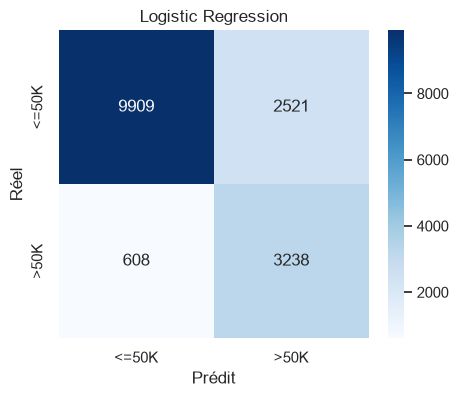


===== Random Forest =====
accuracy: 0.8151
f1_pos: 0.6887
roc_auc: 0.9177
              precision    recall  f1-score   support

       <=50K       0.95      0.80      0.87     12430
        >50K       0.57      0.87      0.69      3846

    accuracy                           0.82     16276
   macro avg       0.76      0.83      0.78     16276
weighted avg       0.86      0.82      0.83     16276



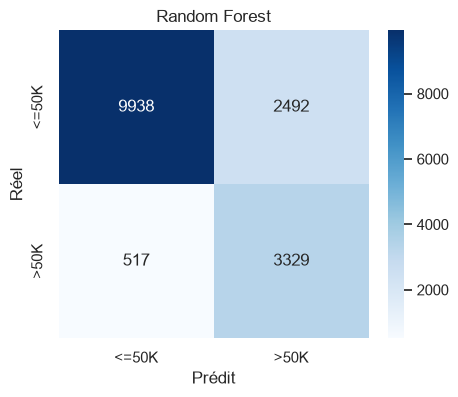

In [18]:
def evaluate_model(name, pipe, X_tr, y_tr, X_te, y_te):
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_te)[:, 1]
    else:
        y_proba = pipe.decision_function(X_te)

    metrics = {
        "accuracy": accuracy_score(y_te, y_pred),
        "f1_pos": f1_score(y_te, y_pred),
        "roc_auc": roc_auc_score(y_te, y_proba),
    }
    print(f"\n===== {name} =====")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    print(classification_report(y_te, y_pred, target_names=["<=50K", ">50K"]))

    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"])
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
    ax.set_title(name)
    plt.show()
    return pipe


fitted = {}
for name, pipe in models.items():
    fitted[name] = evaluate_model(name, pipe, X_train, y_train, X_test, y_test)

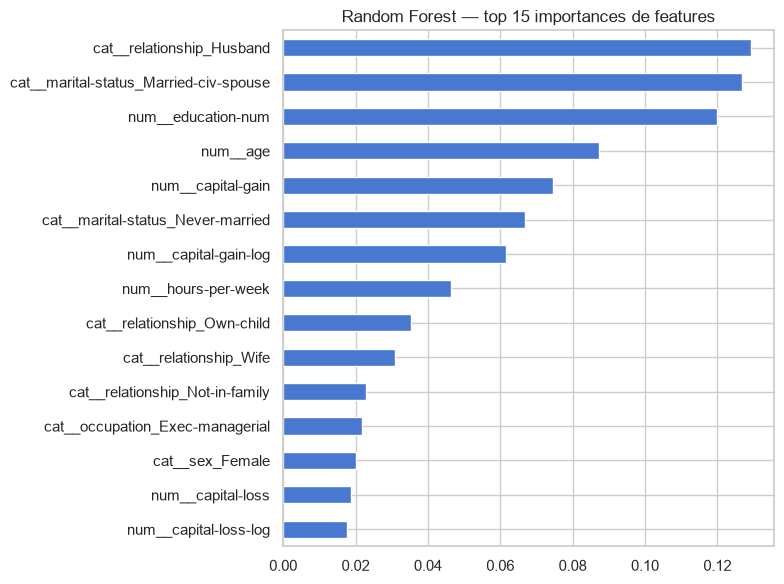

In [19]:
rf_pipe = fitted["Random Forest"]
prep = rf_pipe.named_steps["prep"]
clf = rf_pipe.named_steps["clf"]

feature_names = prep.get_feature_names_out()
importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(15).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Random Forest — top 15 importances de features")
plt.tight_layout()
plt.show()

### Synthèse finale (à compléter après exécution)

1. **Exploration** : déséquilibre des classes, manquants localisés, variables capital très skewed.
2. **Préparation** : imputation, features log, exclusion fnlwgt/education texte, export CSV.
3. **Segmentation** : k choisi par silhouette ; profils moyens par cluster.
4. **Classification** : comparer F1/ROC-AUC entre LR et RF ; discuter faux positifs/négatifs (équité, coût métier).
5. **Limites** : biais historiques (race, sexe), données 1994, pas de validation temporelle.

---

## Checklist « pas à pas » (ordre d’exécution)

1. Installer les dépendances (`requirements.txt`).
2. Exécuter **Run All** sur ce notebook.
3. Vérifier les graphiques section 3 et noter 5 observations.
4. Relire le tableau de justification section 4 et ajuster si votre prof le demande (ex. catégorie `Unknown`).
5. Interpréter les profils de clusters (section 5).
6. Comparer les métriques test (section 7) et choisir le modèle à présenter dans le rapport écrit.
7. Remettre : **ce notebook** + **`adult_cleaned_prepared.csv`**.